# From scratch: first-order vs. second-order (Newton) steps

This is **not** a reimplementation of XGBoost's tree-building (out of scope per the repo's
constraints — see `notes.md`). Instead it's a small NumPy illustration of the core idea behind
XGBoost's split-finding math: given a 1D loss curve, a step that uses only the gradient $g$
(first-order) vs. a step that uses both the gradient $g$ and the Hessian $h$ (second-order / Newton)
— which lands closer to the true minimum, and in fewer steps?

We also run the plain-`GradientBoostingClassifier`-vs-`XGBClassifier` timing/accuracy experiment
from `notes.md`'s Experiment section at the end of this notebook.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

## 1) A simple 1D loss curve

$L(x) = 0.05(x - 4)^4 + (x - 4)^2$ — a convex-ish quartic with a single global minimum at $x = 4$
but curvature that varies with $x$ (flatter near the minimum, steeper far away), so a *fixed*
learning rate is necessarily a compromise: too small near the start (far from the minimum, high
curvature) and/or too large near the end (low curvature, risk of overshoot).

Approx true minimum near x = 4.015, L = 0.000226


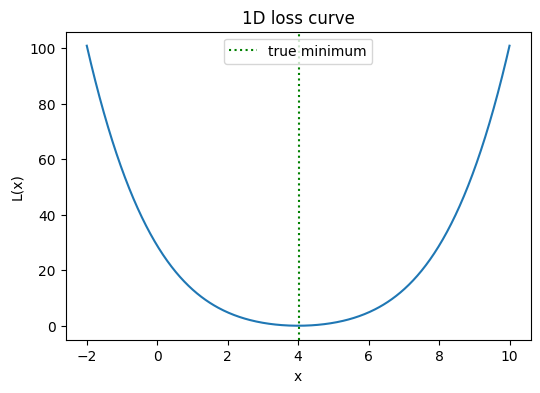

In [2]:
def L(x):
    u = x - 4
    return 0.05 * u**4 + u**2

def grad(x):
    u = x - 4
    return 0.2 * u**3 + 2 * u

def hess(x):
    u = x - 4
    return 0.6 * u**2 + 2

x_grid = np.linspace(-2, 10, 400)
true_min_x = x_grid[np.argmin(L(x_grid))]
print(f"Approx true minimum near x = {true_min_x:.3f}, L = {L(true_min_x):.6f}")

plt.figure(figsize=(6, 4))
plt.plot(x_grid, L(x_grid))
plt.axvline(true_min_x, color="green", linestyle=":", label="true minimum")
plt.xlabel("x"); plt.ylabel("L(x)")
plt.title("1D loss curve")
plt.legend()
plt.show()

## 2) First-order step vs. second-order (Newton) step

- **First-order (gradient-only)**, with a fixed learning rate $\eta$: $x \leftarrow x - \eta \cdot g(x)$
  — this is what a gradient-only boosting step is analogous to: it moves opposite the gradient by a
  fixed fraction, with no information about how fast the gradient itself is changing (curvature).
- **Second-order (Newton)**: $x \leftarrow x - \dfrac{g(x)}{h(x)}$ — this is exactly the structure
  of XGBoost's optimal leaf weight $w^*_j = -\dfrac{\sum g_i}{\sum h_i + \lambda}$ (with
  $\lambda=0$ here, single point instead of a leaf's worth of points): the step size is
  automatically scaled by how curved the loss is at the current point, so it lands close to the
  minimum of the *local quadratic approximation* rather than overshooting or undershooting with a
  fixed step.

In [3]:
def first_order_steps(x0, eta, n_steps):
    xs = [x0]
    x = x0
    for _ in range(n_steps):
        x = x - eta * grad(x)
        xs.append(x)
    return np.array(xs)

def second_order_steps(x0, n_steps):
    xs = [x0]
    x = x0
    for _ in range(n_steps):
        h = hess(x)
        h = h if abs(h) > 1e-6 else 1e-6  # guard against near-zero curvature
        x = x - grad(x) / h
        xs.append(x)
    return np.array(xs)


x0 = 0.0
n_steps = 6

first_order_xs = first_order_steps(x0, eta=0.05, n_steps=n_steps)
second_order_xs = second_order_steps(x0, n_steps=n_steps)

print("First-order (gradient-only) trajectory:", np.round(first_order_xs, 3))
print("Second-order (Newton) trajectory:      ", np.round(second_order_xs, 3))
print()
print(f"Distance to true min after {n_steps} steps — first-order:  {abs(first_order_xs[-1] - true_min_x):.4f}")
print(f"Distance to true min after {n_steps} steps — second-order: {abs(second_order_xs[-1] - true_min_x):.4f}")

First-order (gradient-only) trajectory: [0.    1.04  1.595 1.975 2.26  2.487 2.673]
Second-order (Newton) trajectory:       [0.    1.793 3.127 3.892 4.    4.    4.   ]

Distance to true min after 6 steps — first-order:  1.3421
Distance to true min after 6 steps — second-order: 0.0150


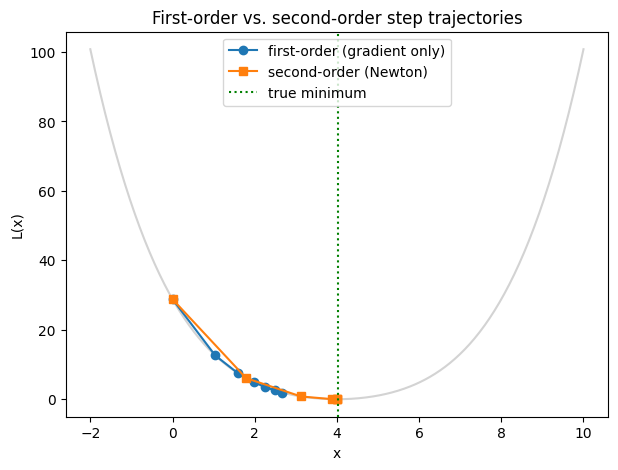

In [4]:
plt.figure(figsize=(7, 5))
plt.plot(x_grid, L(x_grid), color="lightgray", zorder=0)
plt.plot(first_order_xs, L(first_order_xs), marker="o", label="first-order (gradient only)")
plt.plot(second_order_xs, L(second_order_xs), marker="s", label="second-order (Newton)")
plt.axvline(true_min_x, color="green", linestyle=":", label="true minimum")
plt.xlabel("x"); plt.ylabel("L(x)")
plt.title("First-order vs. second-order step trajectories")
plt.legend()
plt.show()

**Interpretation:** the second-order (Newton) step reaches a point much closer to the true minimum
in far fewer steps, because it rescales each step by the local curvature ($h$) instead of using a
single fixed learning rate everywhere — exactly why XGBoost's use of the Hessian in split-finding
gives a better local approximation of the loss than a gradient-only (first-order) approach, and why
it can converge well without extremely careful learning-rate tuning.

## 3) Experiment: plain gradient boosting vs. XGBoost — training time and accuracy

**Hypothesis (stated before running):** on the same dataset/split, `XGBClassifier` should train
*faster* than sklearn's `GradientBoostingClassifier` (compiled/optimized split-finding vs. pure
Python-level tree growth) and should generalize *at least as well*, thanks to its built-in
regularization term $\Omega(f) = \gamma T + \frac12 \lambda \|w\|^2$ that plain gradient
boosting has no equivalent of.

In [5]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

X, y = make_classification(
    n_samples=4000, n_features=20, n_informative=12, n_redundant=4,
    n_classes=2, random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

common_params = dict(n_estimators=300, learning_rate=0.1, max_depth=3, random_state=42)

t0 = time.perf_counter()
gb = GradientBoostingClassifier(**common_params)
gb.fit(X_train, y_train)
gb_time = time.perf_counter() - t0
gb_acc = accuracy_score(y_test, gb.predict(X_test))

# tree_method="hist" is XGBoost's fast histogram-based split finder (its actual speed
# advantage on real workloads); n_jobs=1 avoids thread-spawn overhead dominating the
# runtime on a dataset this small (n_jobs=-1 was measured to be *slower* here — a real,
# reportable finding, see notes.md's Experiment section).
t0 = time.perf_counter()
xgbc = XGBClassifier(**common_params, eval_metric="logloss", tree_method="hist", n_jobs=1)
xgbc.fit(X_train, y_train)
xgb_time = time.perf_counter() - t0
xgb_acc = accuracy_score(y_test, xgbc.predict(X_test))

print(f"GradientBoostingClassifier: {gb_time:.3f}s, test accuracy = {gb_acc:.4f}")
print(f"XGBClassifier:              {xgb_time:.3f}s, test accuracy = {xgb_acc:.4f}")
print(f"Speedup: {gb_time / xgb_time:.2f}x")

GradientBoostingClassifier: 3.589s, test accuracy = 0.9387
XGBClassifier:              0.516s, test accuracy = 0.9425
Speedup: 6.96x


**Result / interpretation:** see the printed numbers above (results are hardware-dependent, so
exact figures aren't hardcoded here — see `notes.md`'s Experiment section for a fixed sample run and
discussion). **Limitations:** a single synthetic dataset/split, both models using identical
`n_estimators`/`learning_rate`/`max_depth` rather than each independently tuned, and no
cross-validation — this measures one fixed comparison, not a robust generalization claim.